# Tarea 2

**Instrucciones**

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a juancaros@udec.cl el dia 20/5 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion.

El archivo a utilizar es panel_eps.csv, que contiene un resumen de la Encuesta de Proteccion Social, en particular la caracterizacion de los individuos en distintas rondas, su situacion laboral y de salud.

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc

# Pregunta 1

Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from sklearn.preprocessing import StandardScaler
import linearmodels.panel as lmp
import seaborn as sns
from linearmodels.iv import IV2SLS
from scipy.stats.mstats import winsorize
from linearmodels.panel import PooledOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy.linalg as la
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

url = "https://raw.githubusercontent.com/juancaros/LAB-MAA/refs/heads/main/data/panel_eps.csv"
df = pd.read_csv(url)
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96846 entries, 0 to 96845
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   folio_n20   96846 non-null  int64  
 1   year        96846 non-null  int64  
 2   time        96846 non-null  int64  
 3   edad        96846 non-null  int64  
 4   hombre      96796 non-null  float64
 5   edu         92920 non-null  float64
 6   region      80848 non-null  float64
 7   status      96736 non-null  float64
 8   kids        96846 non-null  int64  
 9   children    78017 non-null  float64
 10  situation   96846 non-null  int64  
 11  lmp         96846 non-null  int64  
 12  exp         84869 non-null  float64
 13  size        29044 non-null  float64
 14  occupation  49777 non-null  float64
 15  wage        53897 non-null  float64
 16  hours       54576 non-null  float64
 17  informal    41259 non-null  float64
 18  selfemp     55502 non-null  float64
 19  publicemp   55502 non-nul

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,78017.000000,...,0.0,0.0,0.0,0.0,96846.000000,70281.000000,80408.000000,80537.000000,80537.000000,80537.000000
mean,1.253178e+11,7.991213,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,0.741633,...,NaN,NaN,NaN,NaN,13.473432,131.131273,0.361096,0.213144,0.073084,0.074289
std,1.296642e+09,4.566324,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,1.013718,...,NaN,NaN,NaN,NaN,10.354177,216.851544,0.480321,0.409531,0.260277,0.262242
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,4.000000,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,6.000000,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,12.000000,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,8.000000,...,NaN,NaN,NaN,NaN,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
# Eliminamos las columnas que se encuentran completamente vacias
df = df.drop(columns=["fondoa", "fondob", "fondoc", "fondod", "fondoe"], errors="ignore")

# Eliminamos periodos 1 y 6 que producen problemas para trabajar con enfermedades
df = df[~df['time'].isin([1, 6])]

# Corregimos la variable assets que se encuentra con los miles en comas
df["assets"] = df["assets"].replace(",", "", regex=True)
df["assets"] = pd.to_numeric(df["assets"], errors="coerce")

# Correcion de la variable edad si se encuentra en año de nacimiento
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
cond_nacimiento = df["edad"] > 1000
df.loc[cond_nacimiento, "edad"] = (2000 + df.loc[cond_nacimiento, "year"]) - df.loc[cond_nacimiento, "edad"]

# Rellenamos la region usando folio_n20
df["region"] = df.groupby("folio_n20")["region"].transform(lambda x: x.ffill().bfill())

# Creamos variables indicadoras para las variables que tiene % de NaN altos y son datos importantes de saber si responde o no
vars_missing = [
    'informal', 'wage', 'hours', 'selfemp', 'publicemp', 
    'sistema', 'children', 'illness',
    'cronica', 'nocronica', 'mental', 'assets', 'exp'
]

for var in vars_missing:
    df[f'missing_{var}'] = df[var].isna().astype(int)

# Condicionamos las variables que tengan relacion con la situación del empleo de la persona a estudiar
employment_vars = ['informal', 'wage', 'hours', 'selfemp', 'publicemp']

for var in employment_vars:
    employed_mask = (df['situation'] == 3) & df[var].isna()
    not_employed_mask = (df['situation'].isin([1, 2, 4])) & df[var].isna()
    
    if var == 'informal':
        mode_result = df[df['situation'] == 3][var].mode()
        df.loc[employed_mask, var] = mode_result[0] if not mode_result.empty else 0
        df.loc[not_employed_mask, var] = 0

    elif var == 'wage':
        df.loc[employed_mask, var] = df[df['situation'] == 3].groupby( 
            ['edu', 'informal'])[var].transform(
            lambda x: x.median() if not x.isnull().all() else np.nan)
        
        still_na = employed_mask & df[var].isna()
        df.loc[still_na, var] = df[df['situation'] == 3].groupby( 
            ['edu'])[var].transform(
            lambda x: x.median() if not x.isnull().all() else np.nan)
        
        still_na = employed_mask & df[var].isna()
        median_wage = df[df['situation'] == 3][var].median() 
        df.loc[still_na, var] = median_wage if not pd.isna(median_wage) else 0
        df.loc[not_employed_mask, var] = 0
        
    elif var in ['hours']:
        median_value = df[df['situation'] == 3][var].median()
        df.loc[employed_mask, var] = median_value if not pd.isna(median_value) else 0
        df.loc[not_employed_mask, var] = 0
        
    else:  # selfemp, publicemp
        mode_result = df[df['situation'] == 3][var].mode()
        df.loc[employed_mask, var] = mode_result[0] if not mode_result.empty else 0
        df.loc[not_employed_mask, var] = 0

# Imputación para variables no laborales, como salud
other_vars = [
    'expectancy', 'sistema', 'children', 'illness',
    'cronica', 'nocronica', 'mental', 'assets', 'exp'
]

for var in other_vars:
    if df[var].dtype == 'object':
        mode_result = df[var].mode()
        df[var] = df[var].fillna(mode_result[0] if not mode_result.empty else 'unknown')
    else:
        median_value = df[var].median()
        df[var] = df[var].fillna(median_value if not pd.isna(median_value) else 0)

# Se elimina la variable occupation, ya que no se puede imputar con facilidad y registra muchos valores nulos para un dropna
df.drop(columns=["occupation"],inplace=True)

# Creamos variables dummies
df = pd.get_dummies(df, columns=["region", "status", "situation", "lmp"], prefix=["region", "status", "situation", "lmp"], drop_first=True)

# Convertimos todas las columnas tipo bool a int (0/1)
df = df.astype({col: 'int' for col in df.select_dtypes(include='bool').columns})

# Estandarizamos wage y assets por sus valores de alto rango que provoca dispercion de datos
df['wage']=np.log(df['wage']-df['wage'].min()+0.1)
df['assets']=np.log(df['assets']-df['assets'].min()+0.1)

# Arreglamos los valores muy irreales de expectativa de vida
df = df[(df['expectancy'] >= 40) & (df['expectancy'] <= 120)]

edad: 31.00% outliers
folio_n20: 22.87% outliers
cronica: 20.66% outliers
selfemp: 11.32% outliers
sistema: 9.62% outliers
nocronica: 6.68% outliers
mental: 6.62% outliers
informal: 6.27% outliers
publicemp: 6.02% outliers
expectancy: 5.48% outliers
children: 5.34% outliers
size: 5.17% outliers
hours: 0.07% outliers
year: 0.00% outliers
time: 0.00% outliers
hombre: 0.00% outliers
edu: 0.00% outliers
kids: 0.00% outliers
exp: 0.00% outliers
wage: 0.00% outliers
cotizando: 0.00% outliers
assets: 0.00% outliers
exp_sist: 0.00% outliers
illness: 0.00% outliers


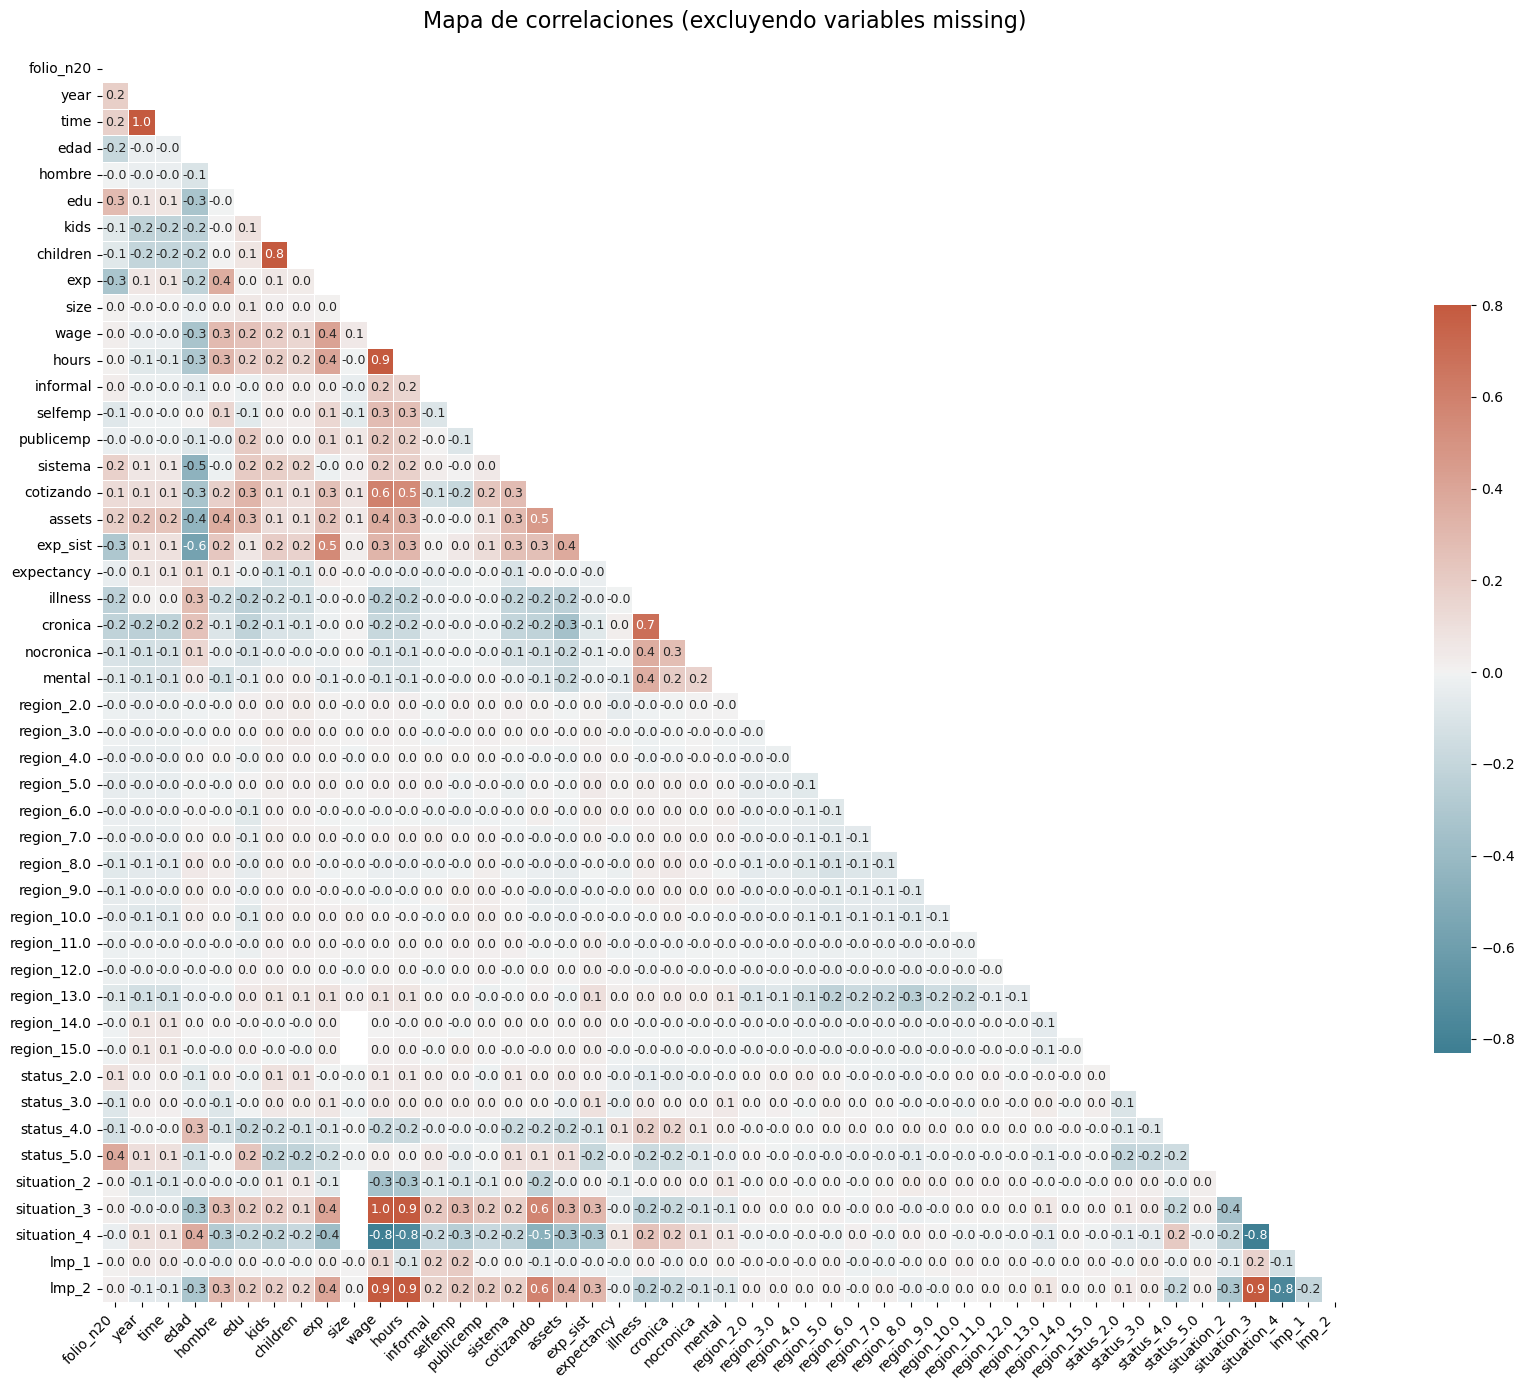

In [5]:
# Vemos el porcentaje de outliers
outlier_counts = {}

# Seleccionamos columnas numéricas que NO son 'missing_...'
numeric_cols = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if not col.startswith("missing_")
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

# Ordenamos de mayor a menor
outlier_counts = dict(sorted(outlier_counts.items(), key=lambda item: item[1], reverse=True))

# Imprimimos en porcentaje
for k, v in outlier_counts.items():
    print(f"{k}: {(v / len(df)) * 100:.2f}% outliers")
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar columnas numéricas que no sean missing
numeric_cols = [col for col in df.select_dtypes(include='number').columns if not col.startswith("missing_")]

# Matriz de correlación
corr = df[numeric_cols].corr()

# Máscara para mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tamaño y estilo
plt.figure(figsize=(18, 14))  # Aumentamos tamaño
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Heatmap
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=0.8,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    annot=True,
    fmt=".1f",
    annot_kws={"size": 9}
)

# Rotar etiquetas
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Mapa de correlaciones (excluyendo variables missing)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [7]:
# Verificar porcentaje de NaN y mostramos solo los que son mayores a 0
nan_percent = df.isna().mean()
print(nan_percent[nan_percent > 0].sort_values(ascending=False))

size         0.683572
cotizando    0.077874
edu          0.014918
hombre       0.000640
dtype: float64


In [9]:
# Eliminamos la variable edad, ya que cuenta con muchas personas de 20 años despues del arreglo, poco probable
df.drop(columns=["edad"],inplace=True)

# Eliminamos la variable size ya que cuenta con muchos valores NaN
df.drop(columns=["size"],inplace=True)

df=df.dropna()
df = df.set_index(["folio_n20","time"])

# Botamos variables que producen colinealidad por alta correlacion 
X = df.drop(columns=[
    'expectancy', 'illness', 'children', 
    'nocronica', 'exp_sist',
])
X = X.loc[:, X.nunique() > 1]  # Quita columnas constantes


#Calcular VIF 
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nResumen de multicolinealidad:")
print(vif_data.sort_values("VIF", ascending=False))


Resumen de multicolinealidad:
             Variable        VIF
47              lmp_2        inf
46              lmp_1        inf
44        situation_3        inf
19  missing_publicemp        inf
18    missing_selfemp        inf
45        situation_4  86.020882
5                wage  69.168062
43        situation_2  33.425190
17      missing_hours  20.129933
16       missing_wage  12.605410
6               hours   9.958389
15   missing_informal   8.083147
36        region_13.0   6.200645
8             selfemp   3.865474
23     missing_assets   3.801392
31         region_8.0   3.480204
0                year   3.247278
28         region_5.0   3.079223
11          cotizando   2.909874
30         region_7.0   2.493160
33        region_10.0   2.452607
29         region_6.0   2.287074
32         region_9.0   2.144311
12             assets   2.123751
27         region_4.0   2.000256
24        missing_exp   1.912743
20    missing_sistema   1.841572
10            sistema   1.556848
4           

In [11]:
# Eliminar variables con VIF infinito
high_vif = vif_data[vif_data["VIF"] > 1000]['Variable']
X = X.drop(columns=high_vif)

# Pregunta 2

Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [13]:
# Creamos nuestra variable dependiente
y=df['expectancy']

df_clean = pd.concat([y, X], axis=1)
y_clean = df_clean['expectancy']
X_clean = sm.add_constant(df_clean.drop(columns=['expectancy']))

#Ajustar el modelo con PooledOLS
model = lmp.PanelOLS(y_clean, X_clean);
results = model.fit()

print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0514
Estimator:                   PanelOLS   R-squared (Between):              0.0728
No. Observations:               54125   R-squared (Within):               0.0009
Date:                Tue, May 20 2025   R-squared (Overall):              0.0514
Time:                        20:47:02   Log-likelihood                -1.978e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      68.123
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(43,54081)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             68.123
                            

# Respuesta Pregunta 2

Dentro y gracias a estos resultados podemos concluir diferentes relaciones entre las variables y la expectativa de vida.

Por ejemplo:

la educación, observamos que es significativa, y cuenta con un coeficiente de 0.049, esto nos quiere decir que cada año adicional de educación completada, la expectativa de vida aumenta en aproximadamente unos 18 días (0.049 años). 

También podemos observar que los hombres viven en promedio 1.4 años más que las mujeres, y que tener hijos esta relacionado con una disminución de la esperanza o expectativa de vida.

Otras variables asociadas al trabajo que podemos relacionar con la expectativa de vida son, los ingresos y la experiencia laboral, las cuales se asocian positivamente con nuestra expectativa de vida, al contrario de las horas de trabajo, ya que mientras más horas de trabajo a la semana tengamos puede producir un desgaste que reduce la expectativa de vida, igual que trabajar informalmente (sin contrato), esto esta relacionado con las cotizaciones de las personas, ya que cotizar aumenta positivamente a la expectativa de vida, cosa que una persona informal no recibe, es por eso que trabajar informalmente reduce la expectativa.

la variabilidad explicada dentro de los individuos es baja, pero relevante para entender cambios longitudinales.

# Pregunta 3

Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [15]:
y=df['expectancy']

# Variables a ocupar dado resultados anteriores para usar en efectos fijos
X = df[[
    'year',           
    'hours',
    'wage',
    'assets',
    'mental',
    'edu',         
    'kids',          
    'exp',         
    'sistema',      
    'cronica',     
    'informal',
    'selfemp',
    'cotizando',
    'region_3.0',
    'region_8.0',   
    'region_15.0',
    'situation_2',    
    'missing_assets', 
    'missing_sistema',
    'missing_wage',
    'missing_hours',
]]

y_clean = df_clean['expectancy']
X_clean = sm.add_constant(X)

#Ajustar el modelo con efectos fijos
model_fe = lmp.PanelOLS(y_clean, X_clean, entity_effects=True)
fe_results = model_fe.fit(cov_type="robust")

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0140
Estimator:                   PanelOLS   R-squared (Between):             -0.0128
No. Observations:               54125   R-squared (Within):               0.0140
Date:                Tue, May 20 2025   R-squared (Overall):             -0.0007
Time:                        20:47:10   Log-likelihood                -1.744e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      21.113
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(21,31206)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             16.828
                            

# Respuesta Pregunta 3

Luego de escoger nuestras variables a interpretar para nuestro modelo de efectos fijos, obtuvimos los siguientes resultados.

Seguimos manteniendo que un aumento en los ingresos y en la experiencia laboral, permiten obtener una mayor expectativa de vida, esto puede ser debido a la estabilidad laboral que uno consigue cuando trabaja durante más años y obtiene más experiencia, que a su vez permite un aumento en los ingresos.

Hablando de salud, concluimos que tener enfermedades mentales y enfermedades cronicas producen una disminución considerable en nuestra expectativa de vida. 

También nuestra expectativa de vida aumenta con cotizar en el sistema de previsiones como mencionamos anteriormente.

la variabilidad explicada dentro de los individuos es baja, pero relevante para entender cambios longitudinales.

# Pregunta 4

Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [17]:
model=lmp.RandomEffects(y_clean,X_clean)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3538
Estimator:              RandomEffects   R-squared (Between):              0.0493
No. Observations:               54125   R-squared (Within):               0.0054
Date:                Tue, May 20 2025   R-squared (Overall):              0.0363
Time:                        20:47:24   Log-likelihood                -1.894e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1410.5
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(21,54103)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             77.027
                            

# Respuesta Pregunta 4 

Podemos observar que el R2 aumenta considerablemente respecto a los modelos anteriores, esto puede deberse a la ventaja de poder capturar la variabilidad entre individuos y tambien dentro del mismo individuo, a diferencia del modelo de efectos fijos.

Seguimos manteniendo que mayores ingresos mejoran nuestra expectativa, y que enfermedades mentales producen una disminución en esta, tambien observamos que tener hijos produca una disminución, lo que puede deberse posiblemente al estrés que contrae o a la carga económica de tener un hijo. 

También mantenemos que la experiencia de vida mejora nuestra expectativa de vida, y que trabajar informal la reduce, debido a lo mismo explicado en la respuesta anterior.

Otro factor que podemos agregar y que es importante es que, la cesantia (situación 2) produce una disminución en la expectativa de vida, y tiene sentido debido a que, no cotizamos, no tenemos ingreso, y se relaciona con las variables mencionadas anteriormente.

# Pregunta 5

Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [19]:
def hausman(fe_results, re):
    # ⚠️ Tomar solo los coeficientes comunes entre ambos modelos
    common_idx = fe_results.params.index.intersection(re.params.index)
    
    b_fe = fe_results.params[common_idx]
    b_re = re.params[common_idx]
    
    # ⚠️ Covarianzas alineadas
    V_fe = fe_results.cov.loc[common_idx, common_idx]
    V_re = re.cov.loc[common_idx, common_idx]
    
    diff = b_fe - b_re
    psi = V_fe - V_re
    
    # ⚠️ Evitar problemas de singularidad
    try:
        W = float(diff.T @ la.inv(psi) @ diff)
        dof = len(diff)
        pval = stats.chi2.sf(W, dof)
    except la.LinAlgError:
        W, dof, pval = float("nan"), len(diff), float("nan")
        print("⚠️ Error: Matriz singular. El test de Hausman no se puede calcular con estos datos.")
    
    return W, dof, pval

# Ejecutar el test con tus modelos
htest = hausman(fe_results, re)

# Mostrar resultados
print("Hausman Test: chi-2 = {:.3f}, df = {}, p-value = {}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 432.413, df = 22, p-value = 8.169363520840956e-78


# Respuesta Pregunta 5

Según el modelo de Hausman nos indica que el modelo de efectos fijos es mejor, a pesar de su r2 menor a el de efectos randoms, esto puede deberse a distintos factores, tales como, que el de efectos aleatorios usa tanto las variaciones dentro de los individuos como fuera, lo que produce un aumento en el r2, también, estamos tratando de decidir cuál modelo es estadisticamente mejor o más válido, no cual se ajusta de mejor manera en el r2. Por ultimo esto tambíen puede deberse a la existencia de un sesgo dentro de las pruebas estadisticas. 

Pero vemos también que los efectos randoms se obtuvo muy robusta, y considerando su gran r2, a pesar de lo dicho anteriormente esta puede ser una mejor opción por sus ventajas de usar variaciones tanto fuera como dentro de los individuos. 

Algunas de las variables más robustas obtenidas fueron, la salud mental, la experiencia laboral, si tenemos o no hijos, si se trabaja informal y finalmente si se cotiza o no. 

(mental, exp, kids, sistema, informal y cotizando)

# Problema 6

Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [21]:
X = df.drop(['expectancy'], axis=1, inplace=False)
Xm = X.groupby(by = 'folio_n20').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(df,Xm, left_index=True, right_index=True)
Y = Xc['expectancy']
X = Xc[['mwage','wage','medu','edu','mkids','kids','mexp','exp','msistema','sistema','year','cronica','mental','assets','region_3.0',
      'region_8.0','region_15.0','situation_2','missing_assets','missing_sistema','missing_wage','missing_hours','hours','informal','selfemp','cotizando']]
X=sm.add_constant(X)

model=lmp.RandomEffects(y,X)
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3570
Estimator:              RandomEffects   R-squared (Between):              0.0524
No. Observations:               54125   R-squared (Within):               0.0113
Date:                Tue, May 20 2025   R-squared (Overall):              0.0407
Time:                        20:47:36   Log-likelihood                -1.893e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1155.1
Entities:                       22898   P-value                           0.0000
Avg Obs:                       2.3637   Distribution:                F(26,54098)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             76.997
                            

# Respuesta Pregunta 6

Resumiendo en el modelo de efectos aleatorios correlacionados lo que se hace es, incorporar las medias individuales, que se encuentran con el prefijo de la variable y una m antes, las cuales se aplicaron a ciertas variables independientes, lo que permitió modelar de forma explicita la correlación entre los efectos individuales que no fueron observados y las covariables explicativas. Esto hace que el modelo CRE sea más robusto que el modelo de efectos aleatorios tradicional (RE).

Algunas variables destacadas que podemos encontrar fueron mwage, con el promedio de ingreso, siendo negativo, lo que sugiere que en promedio, mayores ingresos a nivel individual no se asocian con una mayor expectativa de vida, pero dentro de cada individuo si, controlado por otras variables como la experiencia laboral y que tener más dinero ahorrado en nuestras pensiones permite mejor la expectativa de vida.

# Pregunta 7

Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

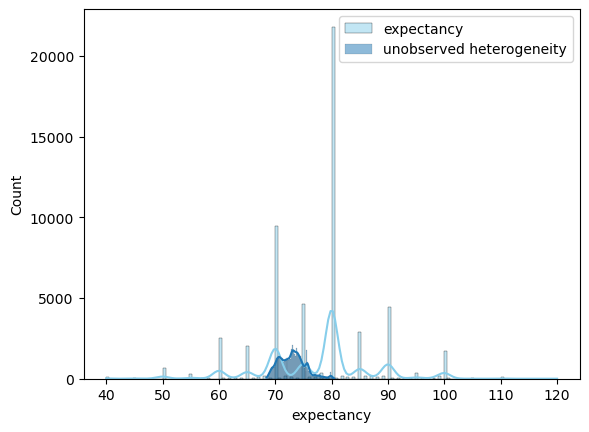

In [23]:
Xpred = X
Xpred['wage']=0
Xpred['edu']=0
Xpred['kids']=0
Xpred['exp']=0
Xpred['sistema']=0
Xpred['year']=0
Xpred['cronica']=0
Xpred['selfemp']=0
Xpred['cotizando']=0
Xpred['hours']=0
Xpred['informal']=0
Xpred['mental']=0
Xpred['assets']=0
Xpred['region_3.0']=0
Xpred['region_8.0']=0
Xpred['region_15.0']=0
Xpred['situation_2']=0
Xpred['missing_assets']=0
Xpred['missing_sistema']=0
Xpred['missing_wage']=0
Xpred['missing_hours']=0
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="expectancy", kde=True)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True)

plt.legend() 
plt.show()

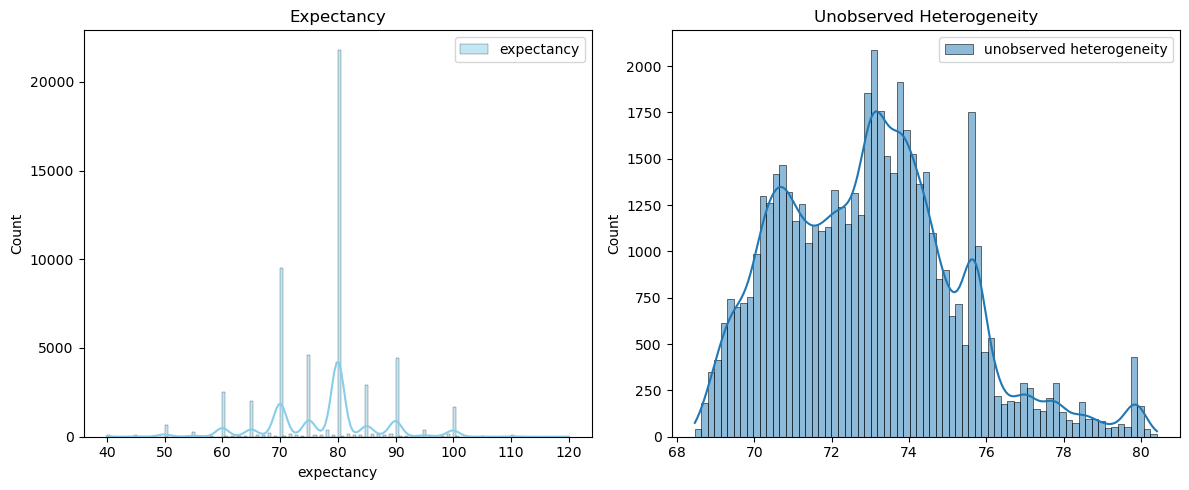

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=y, color="skyblue", label="expectancy", kde=True, ax=ax1)
ax1.set_title('Expectancy')
ax1.legend()

sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True, ax=ax2)
ax2.set_title('Unobserved Heterogeneity')
ax2.legend()

plt.tight_layout()
plt.show()

# Respuesta Pregunta 7

Observando la forma de la distribución podemos observar que es de forma asimétrica hacia la izquierda, y se centra principalmente entre los años 72 y 74, y existe también una gran concentración en un rasgo estrecho, lo que indica homogeneidad relativa en la mayoria de casos. 

En cuanto al grafico de esperanza de vida, observamos una distribución altamente discreta y bimodal, con valores extremos frecuentes, por ejemplo a simple vista en el año 80. En este caso la heterogeneidad no observada, es más suave y continua, lo que indica que el modelo CRE ha extraído un mejor componente que el efecto individual fijo. 

De esto podemos inferir y concluir, que existe heterogeneidad fija relevante, que individuos con mayor valor del componente no observado tienen, una mayor expectativa de vida, y puede deberse a factores o variables no incluidas en los modelos.

# Pregunta 8

Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

In [27]:
print(lmp.compare({"PooledOLS": results, "FE": fe_results, "RE": re, "CRE": cre}))

                                     Model Comparison                                    
                             PooledOLS             FE                RE               CRE
-----------------------------------------------------------------------------------------
Dep. Variable               expectancy     expectancy        expectancy        expectancy
Estimator                     PanelOLS       PanelOLS     RandomEffects     RandomEffects
No. Observations                 54125          54125             54125             54125
Cov. Est.                   Unadjusted         Robust            Robust            Robust
R-squared                       0.0514         0.0140            0.3538            0.3570
R-Squared (Within)              0.0009         0.0140            0.0054            0.0113
R-Squared (Between)             0.0728        -0.0128            0.0493            0.0524
R-Squared (Overall)             0.0514        -0.0007            0.0363            0.0407
F-statisti

# Respuesta Pregunta 8

Luego de la revisión exhaustiva de los distintos modelos estimados (PooledOLS, Efectos fijos, Efectos aleatorios y CRE), el modelo más adecuado es el de efectos aleatorios correlacionados (CRE), debido a que este modelo:

Permite controlar de mejor manera la heterogeneidad no observada que se encuentra fija en el tiempo, lo cual el modelo fijo no permite, también permite la utilizacion del enfoque con medias individuales, lo que relaja el supuesto de no correlaciones entre los efectos individuales y sus regresores, lo que mejora la validez de nuestros estimadores, a su vez es mejor, ya que, combina las ventajas de efectos fijos y aleatorios, siendo más flexible y también más robusto.

Podemos inferir de forma general que las variables que influyen de manera positiva en la expectativa de vida son, mayores ingresos (wage), mayor experiencia laboral (exp), mejor cantidad de ahorros previsionales (assets) y que la persona cotize (cotizando).

En cuanto a las que influyen de manera negativa en la expectativa de vida tenemos, la salud mental (mental), la tenencia de hijos (kids) y, por último los trabajadores informales (informal).

Finalizando, descubrimos que la esperanza de vida esta fuertemente influida por factores socioeconómicos estructurales, como ingresos, formalidades laborales, activos, experiencia y sistemas previsionales.